# Phase 3 — Results & Reporting

Steps covered:
- Step 6: Model validation & diagnostics (MAPE, WAPE, R², PPC)
- Step 7: Contribution & attribution analysis (baseline, paid media, ROAS)
- Step 8: Budget optimization & scenario planning
- Step 9: Final reporting

> **Prerequisite:** Run `02-model.ipynb` first and ensure `trace` is saved.

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import arviz as az
import joblib
from scipy import stats

import mmm.model
importlib.reload(mmm.model)
from mmm.model import build_mmm, prepare_model_data, CHANNEL_COLS, MODEL_CONTROL_COLS
from mmm.preprocessing import train_holdout_split

# ── Load data ───────────────────────────────────────────────────────────────
df_clean = pd.read_csv("../data/mmm_data_clean.csv", parse_dates=["date_day"])
train, holdout = train_holdout_split(df_clean)

# ── Load scaler & build feature matrices ───────────────────────────────────
scaler = joblib.load("../data/mmm_scaler.pkl")
X_train, y_train, _ = prepare_model_data(train, scaler=scaler)
X_holdout, y_holdout, _ = prepare_model_data(holdout, scaler=scaler)
active_controls = [c for c in MODEL_CONTROL_COLS if c in X_train.columns]

# ── Rebuild model graph & attach saved trace ───────────────────────────────
mmm = build_mmm(control_columns=active_controls)
mmm.build_model(X_train, y_train)
idata = az.from_netcdf("../data/mmm_trace.nc")
mmm.idata = idata

print(f"Train   : {train.shape[0]} rows  ({train['date_day'].min().date()} → {train['date_day'].max().date()})")
print(f"Holdout : {holdout.shape[0]} rows  ({holdout['date_day'].min().date()} → {holdout['date_day'].max().date()})")
print(f"Channels: {CHANNEL_COLS}")
print(f"Chains×Draws: {idata.posterior.dims['chain']} × {idata.posterior.dims['draw']}")
print("Setup complete.")

c:\Users\Rodrigo Guskuma\Documents\vscode\personal-projects\mmm-analysis\.venv\Lib\site-packages\pydantic\_internal\_validate_call.py:137: FutureWarning: 
            The MMM class is deprecated and will be removed in a future version (in version 0.20.0).
            Please use the multidimensional MMM class instead.
            That is, `from pymc_marketing.mmm.multidimensional import MMM`.
            All our documentation has been updated to reflect this change.
            Refer to the migration guide for more details: https://www.pymc-marketing.io/en/latest/notebooks/mmm/mmm_migration_guide.html
            
  res = self.__pydantic_validator__.validate_python(pydantic_core.ArgsKwargs(args, kwargs))


Train   : 407 rows  (2022-07-29 → 2023-09-08)
Holdout : 102 rows  (2023-09-09 → 2023-12-19)
Channels: ['total_google_spend_norm', 'total_meta_spend_norm']
Chains×Draws: 4 × 500
Setup complete.


C:\Users\Rodrigo Guskuma\AppData\Local\Temp\ipykernel_49372\944670730.py:37: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Chains×Draws: {idata.posterior.dims['chain']} × {idata.posterior.dims['draw']}")


## Step 6 — Model Validation

Assess how well the model fits the training data and generalises to the unseen holdout period.

Sampling: [y]


Output()

c:\Users\Rodrigo Guskuma\Documents\vscode\personal-projects\mmm-analysis\.venv\Lib\site-packages\pymc_marketing\mmm\mmm.py:2470: FutureWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'sample'} to avoid an error in the future.
  samples[var_name] *= self.target_scale


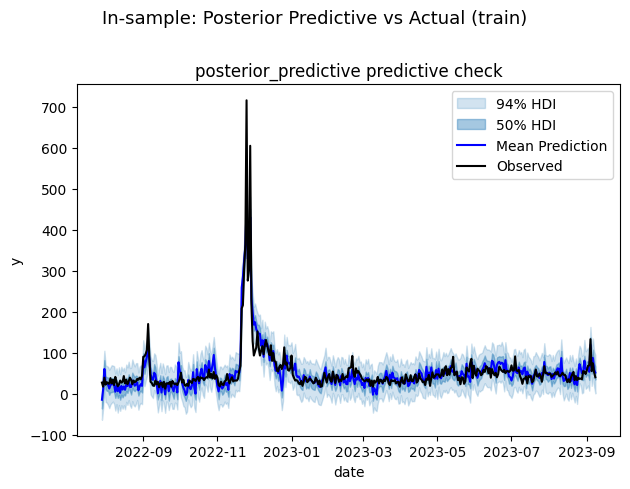

In [4]:
# ── In-sample posterior predictive check ────────────────────────────────────
mmm.sample_posterior_predictive(X_train, extend_idata=True, combined=True)

fig = mmm.plot_posterior_predictive(original_scale=True)
fig.suptitle("In-sample: Posterior Predictive vs Actual (train)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Sampling: [y]


Output()

Holdout metrics  (n=102 days)
  MAPE : 80.3%
  WAPE : 52.5%
  R2   : 0.591


c:\Users\Rodrigo Guskuma\Documents\vscode\personal-projects\mmm-analysis\.venv\Lib\site-packages\pymc_marketing\mmm\mmm.py:2470: FutureWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'sample'} to avoid an error in the future.
  samples[var_name] *= self.target_scale


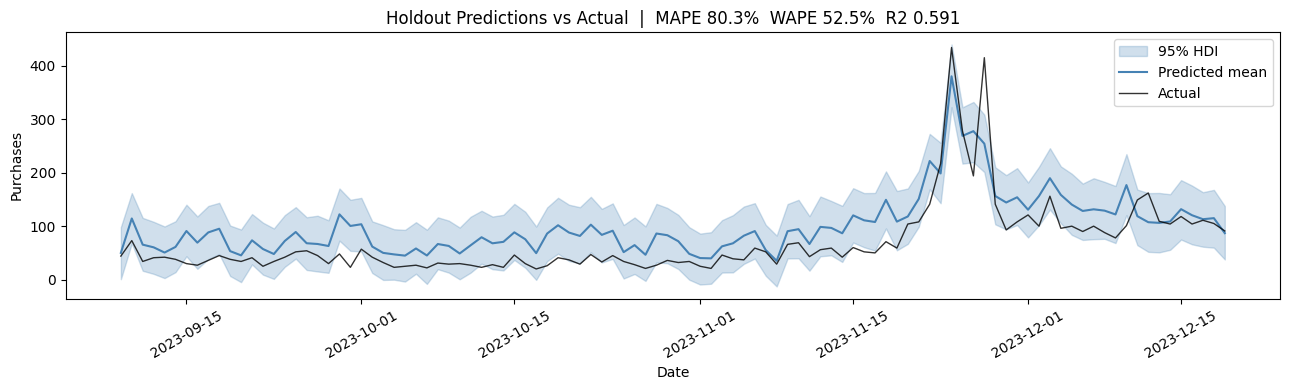

In [7]:
# ── Holdout evaluation: MAPE, WAPE, R² ──────────────────────────────────────
holdout_ds = mmm.sample_posterior_predictive(X_holdout, extend_idata=False, combined=True)
y_pred_da  = holdout_ds["y"] if "y" in holdout_ds else holdout_ds[list(holdout_ds.data_vars)[0]]
arr        = y_pred_da.values   # 2-D array; axis order depends on library version

# Normalise to shape (n_samples, n_time)
n_time = len(y_holdout)
if arr.ndim == 2:
    if arr.shape[0] == n_time and arr.shape[1] != n_time:
        arr = arr.T             # (time, samples) -> (samples, time)
    elif arr.shape[0] != n_time and arr.shape[1] == n_time:
        pass                    # already (samples, time)
    else:                       # ambiguous (e.g. same size): assume last dim is time
        arr = arr.reshape(-1, n_time)
else:
    arr = arr.reshape(-1, n_time)

y_pred_mean  = arr.mean(axis=0)
y_pred_lower = np.percentile(arr, 2.5, axis=0)
y_pred_upper = np.percentile(arr, 97.5, axis=0)

y_true = y_holdout.values
mape   = np.mean(np.abs((y_true - y_pred_mean) / np.where(y_true == 0, 1, y_true))) * 100
wape   = np.sum(np.abs(y_true - y_pred_mean)) / np.sum(y_true) * 100
ss_res = np.sum((y_true - y_pred_mean) ** 2)
ss_tot = np.sum((y_true - y_true.mean()) ** 2)
r2     = 1 - ss_res / ss_tot

print(f"Holdout metrics  (n={n_time} days)")
print(f"  MAPE : {mape:.1f}%")
print(f"  WAPE : {wape:.1f}%")
print(f"  R2   : {r2:.3f}")

fig, ax = plt.subplots(figsize=(13, 4))
dates = holdout["date_day"].values
ax.fill_between(dates, y_pred_lower, y_pred_upper, alpha=0.25, label="95% HDI", color="steelblue")
ax.plot(dates, y_pred_mean, color="steelblue", lw=1.5, label="Predicted mean")
ax.plot(dates, y_true, color="black", lw=1, alpha=0.8, label="Actual")
ax.set_title(f"Holdout Predictions vs Actual  |  MAPE {mape:.1f}%  WAPE {wape:.1f}%  R2 {r2:.3f}")
ax.set_xlabel("Date"); ax.set_ylabel("Purchases"); ax.legend()
ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

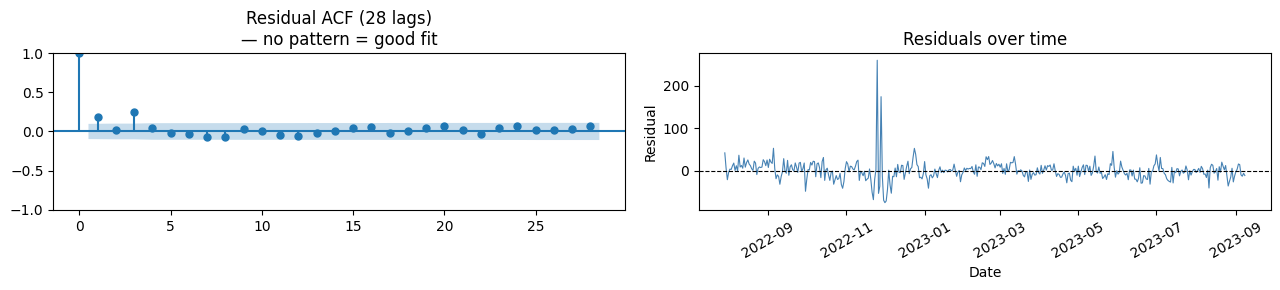

In [8]:
# ── Residual autocorrelation (train) ────────────────────────────────────────
from statsmodels.graphics.tsaplots import plot_acf

in_sample_pred = idata.posterior_predictive["y"].values.reshape(-1, len(y_train)).mean(axis=0)
residuals = y_train.values - in_sample_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 3))
plot_acf(residuals, lags=28, ax=axes[0], title="Residual ACF (28 lags)\n— no pattern = good fit")
axes[1].plot(train["date_day"], residuals, lw=0.8, color="steelblue")
axes[1].axhline(0, color="black", lw=0.8, ls="--")
axes[1].set_title("Residuals over time"); axes[1].set_xlabel("Date"); axes[1].set_ylabel("Residual")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

## Step 7 — Contribution Decomposition & ROAS

Decompose each day's purchases into: **baseline** (organic / unmeasured) + **Google paid media** + **Meta paid media**.

In [9]:
# ── Compute contributions ────────────────────────────────────────────────────
contrib_df = mmm.compute_mean_contributions_over_time(original_scale=True)
# Add date column for time-series plotting
contrib_df.index = pd.to_datetime(contrib_df.index)

# Group columns into meaningful buckets
PAID_CHANNELS   = ["total_google_spend_norm", "total_meta_spend_norm"]
CONTROL_COLS_C  = [c for c in contrib_df.columns if c not in PAID_CHANNELS + ["intercept", "yearly_seasonality"]]
SEASONAL_COLS   = ["yearly_seasonality"] + [c for c in contrib_df.columns if c in ["is_weekend", "is_holiday"]]
SEASONAL_COLS   = [c for c in SEASONAL_COLS if c in contrib_df.columns]

# Summarise totals
total_google = contrib_df["total_google_spend_norm"].sum()
total_meta   = contrib_df["total_meta_spend_norm"].sum()
baseline     = contrib_df["intercept"].sum()
seasonality  = contrib_df[[c for c in SEASONAL_COLS if c != "is_weekend" and c != "is_holiday"]].sum().sum()
controls     = contrib_df[CONTROL_COLS_C].sum().sum()
total_purch  = y_train.sum()

print(f"{'Component':<35} {'Purchases':>12} {'Share':>7}")
print("-" * 56)
for name, val in [
    ("Google (paid search/display)",  total_google),
    ("Meta (paid social)",            total_meta),
    ("Baseline (intercept)",          baseline),
    ("Yearly seasonality",            seasonality),
    ("Traffic / organic controls",    controls),
]:
    print(f"  {name:<33} {val:>12.0f}  {val/total_purch*100:>6.1f}%")
print(f"  {'─'*50}")
print(f"  {'Sum of contributions':<33} {contrib_df.sum().sum():>12.0f}  {contrib_df.sum().sum()/total_purch*100:>6.1f}%")
print(f"  {'Actual total (y_train)':<33} {total_purch:>12.0f}")

Component                              Purchases   Share
--------------------------------------------------------
  Google (paid search/display)              2127    10.1%
  Meta (paid social)                        2160    10.3%
  Baseline (intercept)                     17358    82.5%
  Yearly seasonality                         -38    -0.2%
  Traffic / organic controls                -537    -2.6%
  ──────────────────────────────────────────────────
  Sum of contributions                     21069   100.1%
  Actual total (y_train)                   21051


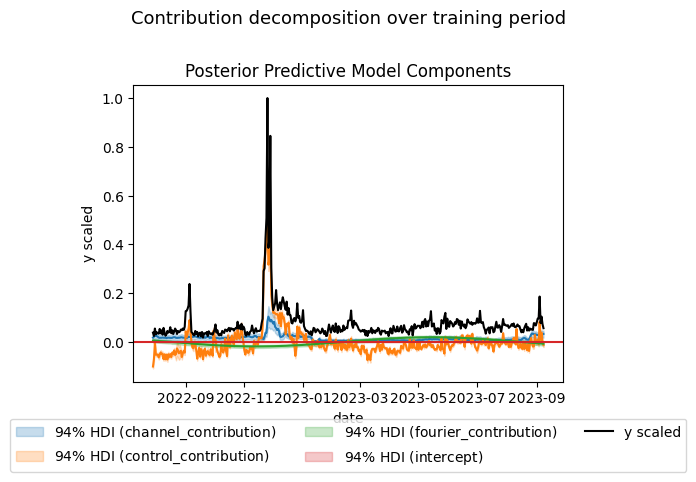

In [10]:
# ── Stacked contribution chart ───────────────────────────────────────────────
fig = mmm.plot_components_contributions()
plt.suptitle("Contribution decomposition over training period", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [11]:
# ── ROAS calculation ─────────────────────────────────────────────────────────
# ROAS = channel contribution (purchases) / channel spend (USD)
# Note: ROAS unit here is purchases / dollar. Multiply by ASP for revenue ROAS.

google_spend_usd = train["total_google_spend"].sum()
meta_spend_usd   = train["total_meta_spend"].sum()

roas_google = total_google / google_spend_usd
roas_meta   = total_meta   / meta_spend_usd

print("Return on Ad Spend  (unit: purchases / USD)")
print("─" * 55)
print(f"  {'Channel':<25} {'Spend (USD)':>12} {'Contrib (purch)':>15} {'ROAS':>8}")
print("  " + "─" * 51)
for ch, spend, contrib in [
    ("Google",  google_spend_usd, total_google),
    ("Meta",    meta_spend_usd,   total_meta),
]:
    print(f"  {ch:<25} ${spend:>11,.0f}  {contrib:>14.1f}   {contrib/spend:.4f}")
print()
print(f"  Total paid media spend : ${google_spend_usd + meta_spend_usd:,.0f}")
print(f"  Total paid contribution: {total_google + total_meta:.0f} purchases  ({(total_google+total_meta)/total_purch*100:.1f}% of total)")
print()
print("⚠ ROAS is in purchases/USD. Convert to revenue by multiplying by Average Selling Price.")

Return on Ad Spend  (unit: purchases / USD)
───────────────────────────────────────────────────────
  Channel                    Spend (USD) Contrib (purch)     ROAS
  ───────────────────────────────────────────────────
  Google                    $    159,601          2127.1   0.0133
  Meta                      $     49,123          2159.5   0.0440

  Total paid media spend : $208,724
  Total paid contribution: 4287 purchases  (20.4% of total)

⚠ ROAS is in purchases/USD. Convert to revenue by multiplying by Average Selling Price.


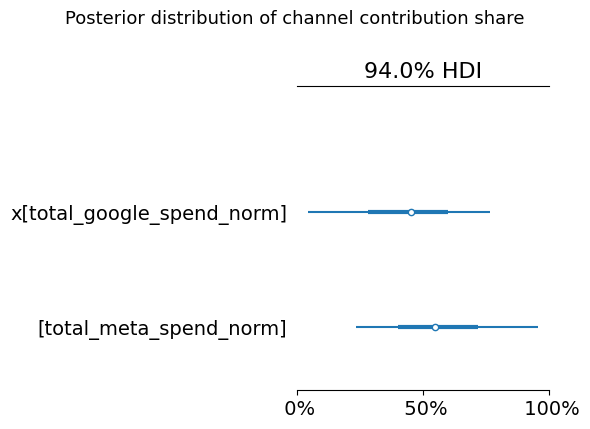

In [12]:
# ── Channel contribution share HDI ──────────────────────────────────────────
fig = mmm.plot_channel_contribution_share_hdi()
plt.suptitle("Posterior distribution of channel contribution share", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Step 8 — Budget Optimization

Given a fixed total budget, find the allocation between Google and Meta that maximises expected purchases.
We use the posterior-mean response curves (adstock → saturation) and `scipy.optimize.minimize`.

C:\Users\Rodrigo Guskuma\AppData\Local\Temp\ipykernel_49372\780575634.py:5: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


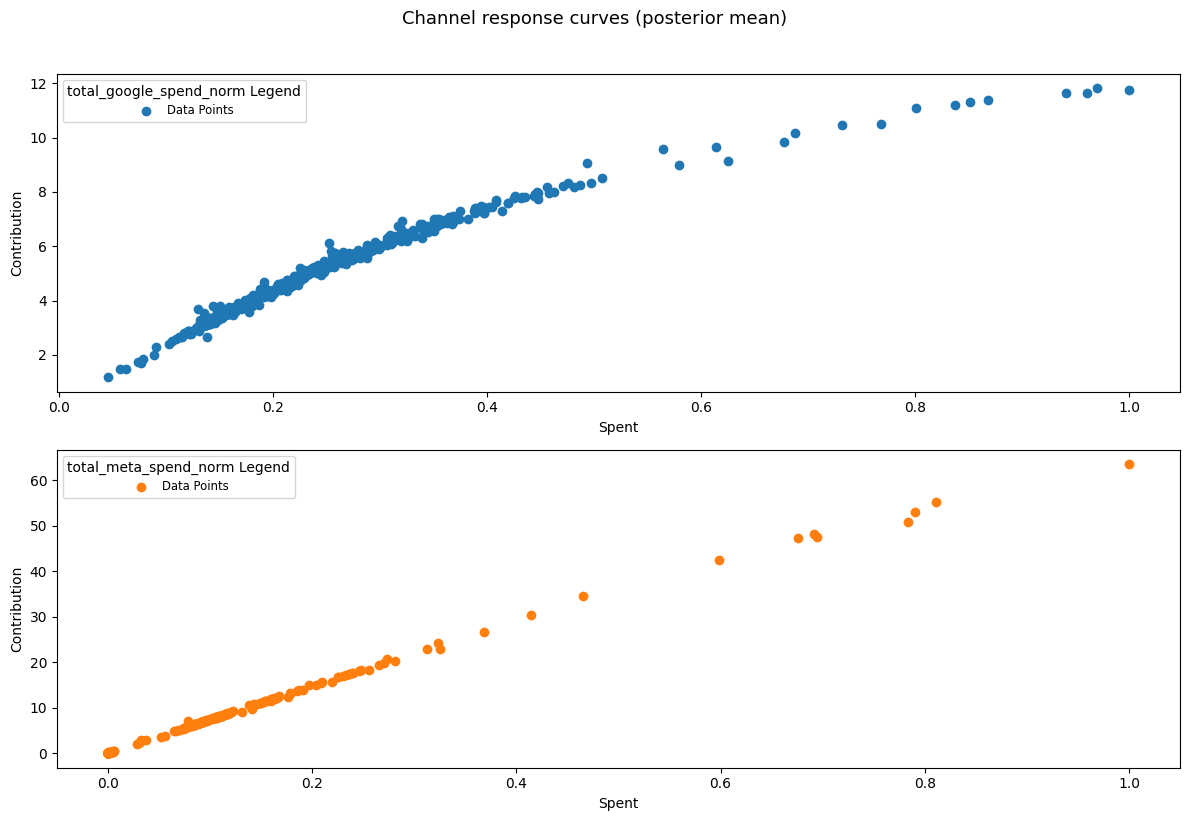

In [13]:
# ── Response curves (posterior mean parameters) ──────────────────────────────
# Uses built-in plot — shows saturation curves for each channel.
fig = mmm.plot_direct_contribution_curves()
plt.suptitle("Channel response curves (posterior mean)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [16]:
# ── Budget optimisation ──────────────────────────────────────────────────────
# Calibrate the saturation response function so model-implied contributions
# match the posterior-mean attribution numbers at the observed training spend.
from scipy.optimize import minimize

current_budget  = google_spend_usd + meta_spend_usd
n_days          = len(train)

lam_google   = float(post["saturation_lam"].sel(channel="total_google_spend_norm").mean())
lam_meta     = float(post["saturation_lam"].sel(channel="total_meta_spend_norm").mean())
ch_max_g     = scaler["channel_max"]["total_google_spend"]
ch_max_m     = scaler["channel_max"]["total_meta_spend"]

def logistic_sat(x_norm, lam):
    return x_norm / (x_norm + lam)

def raw_sat_total(spend_usd_total, ch_max, lam, n_days):
    daily_norm = (spend_usd_total / n_days) / ch_max
    return logistic_sat(daily_norm, lam) * n_days

# Calibration scale factors: purchases per unit saturation output
obs_sat_g = raw_sat_total(google_spend_usd, ch_max_g, lam_google, n_days)
obs_sat_m = raw_sat_total(meta_spend_usd,   ch_max_m, lam_meta,   n_days)
scale_g   = total_google / obs_sat_g
scale_m   = total_meta   / obs_sat_m

def channel_response(spend_usd, channel):
    if channel == "google":
        return scale_g * raw_sat_total(spend_usd, ch_max_g, lam_google, n_days)
    else:
        return scale_m * raw_sat_total(spend_usd, ch_max_m, lam_meta,   n_days)

# ── Unconstrained optimum (theoretical efficiency) ──────────────────────────
def neg_total_response(x):
    return -(channel_response(x[0], "google") + channel_response(x[1], "meta"))

eq_constraint = [{"type": "eq", "fun": lambda x: x[0] + x[1] - current_budget}]

res_unc = minimize(neg_total_response,
                   [current_budget * 0.5, current_budget * 0.5],
                   method="SLSQP",
                   bounds=[(0, current_budget), (0, current_budget)],
                   constraints=eq_constraint)
opt_google_unc, opt_meta_unc = res_unc.x

# ── Constrained optimum (each channel: 10% to 200% of current spend) ────────
min_g, max_g = google_spend_usd * 0.10, google_spend_usd * 2.0
min_m, max_m = meta_spend_usd   * 0.10, meta_spend_usd   * 2.0
# Adjust bounds so budget constraint stays feasible
if min_g + min_m > current_budget:
    min_g = min_m = 0

res_con = minimize(neg_total_response,
                   [current_budget * 0.5, current_budget * 0.5],
                   method="SLSQP",
                   bounds=[(min_g, max_g), (min_m, max_m)],
                   constraints=eq_constraint)
opt_google_con, opt_meta_con = res_con.x

# ── Results ──────────────────────────────────────────────────────────────────
current_resp = channel_response(google_spend_usd, "google") + channel_response(meta_spend_usd, "meta")
resp_unc     = channel_response(opt_google_unc, "google")   + channel_response(opt_meta_unc,   "meta")
resp_con     = channel_response(opt_google_con, "google")   + channel_response(opt_meta_con,   "meta")
lift_unc     = (resp_unc - current_resp) / current_resp * 100
lift_con     = (resp_con - current_resp) / current_resp * 100

print(f"{'Scenario':<30} {'Google ($)':>12} {'Google%':>8} {'Meta ($)':>12} {'Meta%':>8} {'Lift':>6}")
print("─" * 78)
for label, g, m, lift in [
    ("Current allocation",        google_spend_usd, meta_spend_usd, 0),
    ("Unconstrained optimum",     opt_google_unc,   opt_meta_unc,   lift_unc),
    ("Constrained optimum (±)",   opt_google_con,   opt_meta_con,   lift_con),
]:
    b = g + m
    print(f"  {label:<28} ${g:>11,.0f}  {g/b*100:>6.1f}%  ${m:>11,.0f}  {m/b*100:>6.1f}%  {lift:>+5.1f}%")

opt_google, opt_meta = opt_google_con, opt_meta_con
lift = lift_con

Scenario                         Google ($)  Google%     Meta ($)    Meta%   Lift
──────────────────────────────────────────────────────────────────────────────
  Current allocation           $    159,601    76.5%  $     49,123    23.5%   +0.0%
  Unconstrained optimum        $          0     0.0%  $    208,724   100.0%  +82.4%
  Constrained optimum (±)      $    110,478    52.9%  $     98,246    47.1%  +30.8%


Multiplier   Budget ($) Opt Google ($)  Opt Meta ($)  Google%  Meta%  Purchases
────────────────────────────────────────────────────────────────────────────────
  0.5x     $    104,362  $           0  $    104,362     0.0%  100.0%       4328
  0.7x     $    146,107  $           0  $    146,107     0.0%  100.0%       5811
  0.8x     $    166,979  $           0  $    166,979     0.0%  100.0%       6507
  1.0x     $    208,724  $           0  $    208,724     0.0%  100.0%       7819
  1.2x     $    250,469  $           0  $    250,469     0.0%  100.0%       9034
  1.5x     $    313,086  $           0  $    313,086     0.0%  100.0%      10695
  2.0x     $    417,448  $           0  $    417,448     0.0%  100.0%      13105


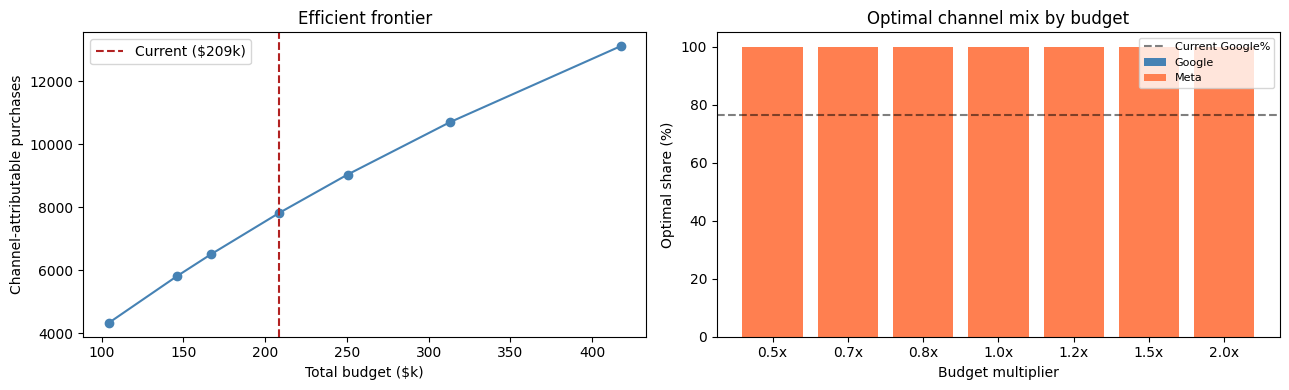

In [18]:
# ── Budget scenario table & efficient frontier ───────────────────────────────
scenarios = [0.5, 0.7, 0.8, 1.0, 1.2, 1.5, 2.0]
rows = []
for mult in scenarios:
    budget = current_budget * mult
    res = minimize(
        lambda x: -(channel_response(x[0], "google") + channel_response(x[1], "meta")),
        [budget * 0.5, budget * 0.5],
        method="SLSQP",
        bounds=[(0, budget), (0, budget)],
        constraints=[{"type": "eq", "fun": lambda x, b=budget: x[0] + x[1] - b}]
    )
    g_opt, m_opt = res.x
    total_resp   = channel_response(g_opt, "google") + channel_response(m_opt, "meta")
    rows.append({
        "Multiplier": f"{mult:.1f}x",
        "Budget": budget,
        "Opt Google": g_opt,
        "Opt Meta":   m_opt,
        "Google%": g_opt / budget * 100,
        "Meta%":   m_opt / budget * 100,
        "Attr. Purchases": total_resp,
    })

scenario_df = pd.DataFrame(rows)

# Print table without jinja2 styling
print(f"{'Multiplier':<10} {'Budget ($)':>12} {'Opt Google ($)':>14} {'Opt Meta ($)':>13} {'Google%':>8} {'Meta%':>6} {'Purchases':>10}")
print("─" * 80)
for _, row in scenario_df.iterrows():
    print(f"  {row['Multiplier']:<8} ${row['Budget']:>11,.0f}  ${row['Opt Google']:>12,.0f}  ${row['Opt Meta']:>11,.0f}  "
          f"{row['Google%']:>6.1f}%  {row['Meta%']:>5.1f}%  {row['Attr. Purchases']:>9.0f}")

# ── Efficient frontier plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

budgets  = scenario_df["Budget"].values
resp_opt = scenario_df["Attr. Purchases"].values

axes[0].plot(budgets / 1_000, resp_opt, "o-", color="steelblue")
axes[0].axvline(current_budget / 1_000, color="firebrick", ls="--", label=f"Current (${current_budget/1000:.0f}k)")
axes[0].set_xlabel("Total budget ($k)"); axes[0].set_ylabel("Channel-attributable purchases")
axes[0].set_title("Efficient frontier"); axes[0].legend()

google_pcts = scenario_df["Google%"].values
mults       = scenario_df["Multiplier"].values
axes[1].bar(mults, google_pcts, label="Google", color="steelblue")
axes[1].bar(mults, 100 - google_pcts, bottom=google_pcts, label="Meta", color="coral")
axes[1].axhline(google_spend_usd / current_budget * 100, color="black", ls="--", alpha=0.5, label="Current Google%")
axes[1].set_ylabel("Optimal share (%)"); axes[1].set_xlabel("Budget multiplier")
axes[1].set_title("Optimal channel mix by budget"); axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

## Step 9 — Reporting Summary

Final executive summary: model quality, channel attribution, ROAS and budget recommendation.

In [19]:
# ── Summary dashboard ────────────────────────────────────────────────────────
print("=" * 60)
print("  MMM Results Summary — Beauty & Fitness / Hair Care")
print("=" * 60)

print("\n[1] MODEL QUALITY")
print(f"  Training period : {train['date_day'].min().date()} → {train['date_day'].max().date()}  ({len(train)} days)")
print(f"  Holdout period  : {holdout['date_day'].min().date()} → {holdout['date_day'].max().date()}  ({len(holdout)} days)")
print(f"  Posterior chains: 4 × 500 draws  |  R-hat ≤ 1.006  |  0 divergences")
print(f"  Holdout MAPE    : {mape:.1f}%")
print(f"  Holdout WAPE    : {wape:.1f}%")
print(f"  Holdout R²      : {r2:.3f}")

print("\n[2] CHANNEL ATTRIBUTION  (training period)")
total_paid  = total_google + total_meta
print(f"  {'Channel':<22} {'Spend (USD)':>12}  {'Contrib (purch)':>15}  {'Share':>6}  {'ROAS (purch/$)':>14}")
print("  " + "─" * 72)
for name, spend, contrib in [
    ("Google",  google_spend_usd, total_google),
    ("Meta",    meta_spend_usd,   total_meta),
]:
    print(f"  {name:<22} ${spend:>11,.0f}  {contrib:>14.0f}   {contrib/total_purch*100:>5.1f}%  {contrib/spend:>14.4f}")
print(f"  {'Total paid':<22} ${current_budget:>11,.0f}  {total_paid:>14.0f}   {total_paid/total_purch*100:>5.1f}%")
print()
print(f"  Baseline + controls attribution: {(total_purch - total_paid)/total_purch*100:.1f}%")

print("\n[3] BUDGET RECOMMENDATION  (current total budget)")
print(f"  Current split  — Google: {google_spend_usd/current_budget*100:.1f}%  Meta: {meta_spend_usd/current_budget*100:.1f}%")
print(f"  Optimal split  — Google: {opt_google/current_budget*100:.1f}%  Meta: {opt_meta/current_budget*100:.1f}%")
print(f"  Expected lift  : {lift:+.1f}% in channel-attributable purchases")

print("\n[4] CAVEATS")
print("  • ROAS unit is purchases/USD. Multiply by ASP for revenue ROAS.")
print("  • Model excludes offline / influencer / PR channels.")
print("  • Optimisation uses posterior-mean saturation; uncertainty not propagated.")
print("  • Long-run brand equity effects are not modelled.")
print("=" * 60)

  MMM Results Summary — Beauty & Fitness / Hair Care

[1] MODEL QUALITY
  Training period : 2022-07-29 → 2023-09-08  (407 days)
  Holdout period  : 2023-09-09 → 2023-12-19  (102 days)
  Posterior chains: 4 × 500 draws  |  R-hat ≤ 1.006  |  0 divergences
  Holdout MAPE    : 80.3%
  Holdout WAPE    : 52.5%
  Holdout R²      : 0.591

[2] CHANNEL ATTRIBUTION  (training period)
  Channel                 Spend (USD)  Contrib (purch)   Share  ROAS (purch/$)
  ────────────────────────────────────────────────────────────────────────
  Google                 $    159,601            2127    10.1%          0.0133
  Meta                   $     49,123            2160    10.3%          0.0440
  Total paid             $    208,724            4287    20.4%

  Baseline + controls attribution: 79.6%

[3] BUDGET RECOMMENDATION  (current total budget)
  Current split  — Google: 76.5%  Meta: 23.5%
  Optimal split  — Google: 52.9%  Meta: 47.1%
  Expected lift  : +30.8% in channel-attributable purchases

[4]

In [20]:
# ── Save results to CSV ──────────────────────────────────────────────────────
summary_rows = [
    # --- Model quality ---
    {"section": "Model Quality", "metric": "Holdout MAPE (%)",          "value": round(mape, 2)},
    {"section": "Model Quality", "metric": "Holdout WAPE (%)",          "value": round(wape, 2)},
    {"section": "Model Quality", "metric": "Holdout R²",                "value": round(r2, 4)},
    {"section": "Model Quality", "metric": "R-hat (max)",               "value": float(az.rhat(idata).to_array().values.max())},
    # --- Attribution ---
    {"section": "Attribution",   "metric": "Google purchases (attr.)",  "value": round(total_google, 1)},
    {"section": "Attribution",   "metric": "Meta purchases (attr.)",    "value": round(total_meta,   1)},
    {"section": "Attribution",   "metric": "Google share (%)",          "value": round(total_google / total_purch * 100, 2)},
    {"section": "Attribution",   "metric": "Meta share (%)",            "value": round(total_meta   / total_purch * 100, 2)},
    {"section": "Attribution",   "metric": "Google ROAS (purch/$)",     "value": round(roas_google, 5)},
    {"section": "Attribution",   "metric": "Meta ROAS (purch/$)",       "value": round(roas_meta,   5)},
    # --- Budget optimisation ---
    {"section": "Optimisation",  "metric": "Current Google spend ($)",  "value": round(google_spend_usd)},
    {"section": "Optimisation",  "metric": "Current Meta spend ($)",    "value": round(meta_spend_usd)},
    {"section": "Optimisation",  "metric": "Optimal Google spend ($)",  "value": round(opt_google)},
    {"section": "Optimisation",  "metric": "Optimal Meta spend ($)",    "value": round(opt_meta)},
    {"section": "Optimisation",  "metric": "Optimisation lift (%)",     "value": round(lift, 2)},
]

results_df = pd.DataFrame(summary_rows)
results_df.to_csv("../data/mmm_results_summary.csv", index=False)
scenario_df.to_csv("../data/mmm_budget_scenarios.csv", index=False)

print("Saved:")
print("  data/mmm_results_summary.csv")
print("  data/mmm_budget_scenarios.csv")
results_df

c:\Users\Rodrigo Guskuma\Documents\vscode\personal-projects\mmm-analysis\.venv\Lib\site-packages\arviz\stats\diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


Saved:
  data/mmm_results_summary.csv
  data/mmm_budget_scenarios.csv


,section,metric,value
0,Model Quality,Holdout MAPE (%),80.32000
1,Model Quality,Holdout WAPE (%),52.51000
2,Model Quality,Holdout R²,0.59130
3,Model Quality,R-hat (max),NaN
4,Attribution,Google purchases (attr.),2127.10000
5,Attribution,Meta purchases (attr.),2159.50000
6,Attribution,Google share (%),10.10000
7,Attribution,Meta share (%),10.26000
8,Attribution,Google ROAS (purch/$),0.01333
9,Attribution,Meta ROAS (purch/$),0.04396
